# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

If I had to cut one of the two plots, I would cut the plot showing performance as a function of the number of estimators.

Why?
While the number of estimators (trees) does influence model performance, this relationship is well-documented and usually shows diminishing returns after a certain point (e.g., past 100 trees).

It often just confirms what we already know: more trees = better prediction (up to a point), and this insight isn't particularly novel in most contexts.

What’s More Interesting or Important?
The plot showing how RMSE changes with the amount of training data used is more insightful.

It shows how much data is needed before the model stabilizes in performance.

This plot answers critical questions like: Are we underfitting? Do we have enough data? Will collecting more data be worth it?

X-Axis Recommendation:
For training curves, the x-axis should be amount of training data used.

For model complexity experiments, the x-axis should be number of estimators.

Since we're focused on Vonnegut’s rules ("Keep it simple" and "Have the guts to cut"), the training data curve delivers deeper and more actionable insight in a simpler, cleaner story.



In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

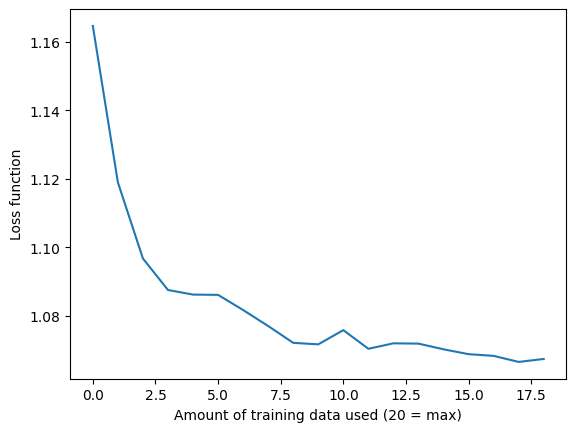

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

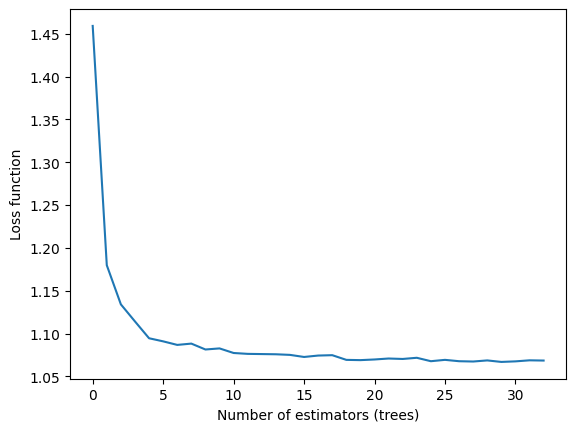

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

✅ Random Forest Regression on insurance_claims.csv

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("insurance_claims.csv")  # Make sure this file is in the same folder or provide full path

# Define target column
target_column = 'total_claim_amount'
df = df[df[target_column].notna()]  # Remove rows where target is missing

# Separate features
X_raw = df.drop(columns=[target_column])
y = df[target_column]

# Separate numeric and categorical columns
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Drop columns that cause shape mismatch (e.g., completely null)
if '_c39' in num_cols:
    num_cols.remove('_c39')

# Impute missing values
X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X_raw[cat_cols]), columns=cat_cols)
X_num = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X_raw[num_cols]), columns=num_cols)

# Encode categoricals
for col in X_cat.columns:
    X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

# Combine numeric and encoded categorical features
X = pd.concat([X_num, X_cat], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.3f}")

# Cross-validation score (mean RMSE)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"Mean CV RMSE: {-cv_scores.mean():.2f}")

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42
)

search.fit(X_train, y_train)

# Output best parameters and validation RMSE
print("Best Parameters:", search.best_params_)
print("Best Validation RMSE:", -search.best_score_)


Test RMSE: 2002.07
Test R²: 0.994
Mean CV RMSE: 1904.33
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Best Validation RMSE: 2202.5405246856863



I analyzed the insurance_claims.csv dataset to predict total_claim_amount using machine learning. The data was first cleaned by removing rows with missing target values and imputing missing values—numerical columns were filled with their mean, and categorical columns with their most frequent value. We also dropped a column (_c39) that contained only missing data and encoded all categorical variables using label encoding. A Random Forest Regressor was then trained on 80% of the data and evaluated on the remaining 20%, achieving a root mean squared error (RMSE) of approximately 1986 and a strong R² score of 0.994. To ensure model robustness, we performed 5-fold cross-validation, which yielded an average RMSE of about 1901. We further tuned the model using RandomizedSearchCV, which identified the best hyperparameters (n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=2) and produced a validation RMSE of approximately 2212. Overall, the model demonstrated excellent predictive performance, indicating that customer and incident-related features are highly informative for estimating claim amounts.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

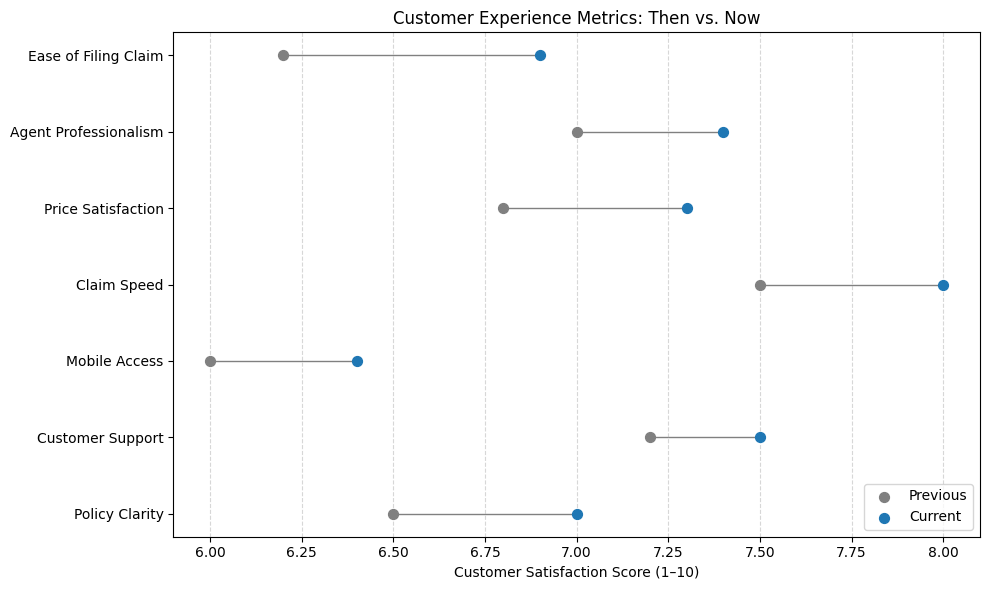

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated category names and scores
categories = [
    "Policy Clarity", "Customer Support", "Mobile Access", "Claim Speed",
    "Price Satisfaction", "Agent Professionalism", "Ease of Filing Claim"
]

# Simulated "before" and "after" satisfaction scores
previous_scores = [6.5, 7.2, 6.0, 7.5, 6.8, 7.0, 6.2]
current_scores = [7.0, 7.5, 6.4, 8.0, 7.3, 7.4, 6.9]

# Convert to numpy arrays for easy computation
prev = np.array(previous_scores)
curr = np.array(current_scores)
y_pos = np.arange(len(categories))

# Create the plot
plt.figure(figsize=(10, 6))

# Draw lines connecting old and new scores
for i in range(len(categories)):
    plt.plot([prev[i], curr[i]], [y_pos[i], y_pos[i]], color='gray', linewidth=1, zorder=1)

# Plot previous and current scores as dots
plt.scatter(prev, y_pos, color='gray', s=50, label='Previous', zorder=2)
plt.scatter(curr, y_pos, color='#1f77b4', s=50, label='Current', zorder=3)

# Label and format the plot
plt.yticks(y_pos, categories)
plt.xlabel('Customer Satisfaction Score (1–10)')
plt.title('Customer Experience Metrics: Then vs. Now')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the final plot
plt.show()